In [2]:
import os

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "Data")

# Config

In [3]:
"""
Residential Density Buffer Analysis
Oakland / Berkeley — Point Layer

Approach:
  - Buffer each point by a chosen radius
  - Intersect buffers with Census block population data
  - Weight population by the proportion of each block's area inside the buffer
  - Report estimated population and residential density per point
"""
import os
import zipfile
import geopandas as gpd
import pandas as pd
from shapely.geometry import mapping
import requests

# CONFIG
POINTS_PATH = os.path.join(DATA_DIR, 'cleaned/stations by year/stations_25.geojson')

BUFFER_METERS = 800                      # (~0.5 mi)
CENSUS_YEAR   = 2022                     # ACS 5-year vintage

COUNTY_FIPS = {
    "Alameda": "001",
}
STATE_FIPS = "06"

# Census variable: total population at block group level
# B01003_001E = Total population (ACS)
CENSUS_VAR = 'B01003_001E'

# LOAD POINTS LAYER
def load_points(path: str) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    return gdf

# Activity and Employment Balance Data
From Gerke paper:

**Activity**: Number of persons and jobs

**Employment-population balance**: Ratio of jobs to persons

In [ ]:
POP_PATH = os.path.join(DATA_DIR, "raw/population/acs5_pop.json")
BLOCKGROUPS_PATH = os.path.join(DATA_DIR, "raw/population/tl_2025_06_bg/tl_2025_06_bg.shp")

# MERGE POPULATION AND GEOMETRY DFS
def merge_dfs(census_var: str):
  raw_json = pd.read_json(POP_PATH)
  pop_df = pd.DataFrame(raw_json.values[1:], columns=raw_json.iloc[0])
  geom_gdf = gpd.read_file(BLOCKGROUPS_PATH)

  pop_df[census_var] = pd.to_numeric(pop_df[census_var], errors="coerce")
  pop_df["GEOID"] = pop_df["state"] + pop_df["county"] + pop_df["tract"] + pop_df["block group"]

  # merge population onto geometries
  merged = geom_gdf.merge(pop_df[["GEOID", census_var]], on="GEOID", how="left")
  merged = merged.rename(columns={census_var: "total_pop"})
  return merged  # CRS is EPSG:4326

In [ ]:
blockgroups_pop = merge_dfs(CENSUS_VAR)
print(f"{len(blockgroups_pop)} block groups fetched")

25607 block groups fetched


In [ ]:
LEHD_WAC_PATH = os.path.join(DATA_DIR, "raw/jobs/ca_wac_S000_JT00_2022.csv.gz")
LEHD_XWALK_PATH = os.path.join(DATA_DIR, "raw/jobs/ca_xwalk.csv.gz")

def load_jobs_by_blockgroup():
    # C000 = total jobs
    wac = pd.read_csv(LEHD_WAC_PATH, usecols=["w_geocode", "C000"])
    xwalk = pd.read_csv(LEHD_XWALK_PATH, usecols=["tabblk2020", "bgrp"], dtype=str)

    # xwalk block code is a string FIPS — match to WAC geocode
    wac["w_geocode"] = wac["w_geocode"].astype(str).str.zfill(15)
    xwalk["tabblk2020"] = xwalk["tabblk2020"].str.zfill(15)

    # join block -> block group
    merged = wac.merge(xwalk, left_on="w_geocode", right_on="tabblk2020", how="left")

    # aggregate to block group
    bg_jobs = merged.groupby("bgrp")["C000"].sum().reset_index()
    bg_jobs = bg_jobs.rename(columns={"bgrp": "GEOID", "C000": "total_jobs"})
    return bg_jobs

def merge_jobs_to_geometry(bg_jobs: pd.DataFrame, blockgroups_with_pop: gpd.GeoDataFrame):
    # blockgroups_with_pop already has total_pop and geometry from your existing code
    merged = blockgroups_with_pop.merge(bg_jobs, on="GEOID", how="left")
    merged["total_jobs"] = merged["total_jobs"].fillna(0)
    merged["activity"] = merged["total_pop"] + merged["total_jobs"]
    merged = merged[merged["COUNTYFP"] == "001"]
    return merged

def buffer_and_intersect(
    points: gpd.GeoDataFrame,
    blockgroups: gpd.GeoDataFrame,
    buffer_meters: int,
) -> gpd.GeoDataFrame:
    # project to a local metric CRS for accurate buffering
    CRS_METRIC = "EPSG:26910"  # UTM Zone 10N — good for Bay Area

    pts_m  = points.to_crs(CRS_METRIC)
    bgs_m  = blockgroups.to_crs(CRS_METRIC)

    # compute full block group area before clipping
    bgs_m["bg_area_m2"] = bgs_m.geometry.area

    buffers = pts_m.copy()
    buffers["geometry"] = pts_m.geometry.buffer(buffer_meters)
    buffers["buffer_area_m2"] = buffers.geometry.area


    results = []

    for idx, buf_row in buffers.iterrows():
        buf_geom = buf_row.geometry

        # clip block groups to this buffer
        clipped = bgs_m.copy()
        clipped["geometry"] = bgs_m.geometry.intersection(buf_geom)
        clipped = clipped[~clipped.geometry.is_empty]
        clipped["clip_area_m2"] = clipped.geometry.area

        # area-weighted population
        clipped["area_weight"] = clipped["clip_area_m2"] / clipped["bg_area_m2"]
        clipped["weighted_pop"] = clipped["total_pop"] * clipped["area_weight"]
        clipped["weighted_jobs"] = clipped["total_jobs"] * clipped["area_weight"]
        clipped["weighted_activity"] = clipped["activity"] * clipped["area_weight"]

        total_jobs = clipped["weighted_jobs"].sum()
        total_activity = clipped["weighted_activity"].sum()

        total_pop = clipped["weighted_pop"].sum()
        buffer_area_km2 = buf_row["buffer_area_m2"] / 1_000_000
        density = total_pop / buffer_area_km2 if buffer_area_km2 > 0 else 0

        row = buf_row.drop("geometry").to_dict()
        row.update({
            "estimated_pop":       round(total_pop),
            "buffer_area_km2":     round(buffer_area_km2, 4),
            "pop_per_km2":         round(density, 1),
            "buffer_radius_m":     buffer_meters,
            "n_blockgroups":       len(clipped),
            "estimated_jobs":     round(total_jobs),
            "estimated_activity": round(total_activity),
            "emp_pop_balance":    round(total_jobs / total_pop, 4) if total_pop > 0 else None,
        })
        results.append(row)

    result_gdf = gpd.GeoDataFrame(results, geometry=buffers.geometry.values, crs=CRS_METRIC)
    return result_gdf.to_crs("EPSG:4326")

In [ ]:
points = load_points(POINTS_PATH)
points = points[~points["id"].str.startswith("SJ")]
print(f"{len(points)} points loaded")

bg_jobs = load_jobs_by_blockgroup()
print(f"{len(bg_jobs)} block groups fetched")
blockgroups = merge_jobs_to_geometry(bg_jobs, blockgroups_pop)

activity_gdf = buffer_and_intersect(points, blockgroups, BUFFER_METERS)

out_csv = os.path.join(DATA_DIR, "cleaned/activity_employment_results.csv")
out_geojson = os.path.join(DATA_DIR, "cleaned/activity_employment_results.geojson")

activity_gdf.drop(columns="geometry").to_csv(out_csv, index=False)
activity_gdf.to_file(out_geojson, driver="GeoJSON")

print(f"files saved")

154 points loaded
25557 block groups fetched
files saved


In [ ]:
activity_gdf

,id,start_count,end_count,combined_count,name,lat,long,buffer_area_m2,estimated_pop,buffer_area_km2,pop_per_km2,buffer_radius_m,n_blockgroups,estimated_jobs,estimated_activity,emp_pop_balance,geometry
0,BK-A3,1613,1517,3130,College Ave at Alcatraz Ave,37.851376,-122.252523,2.007391e+06,9668,2.0074,4816.2,800,16,5448,15116,0.5635,"POLYGON ((-122.24343 37.85132, -122.24348 37.8..."
1,BK-A7,3905,3879,7784,Vine St at Shattuck Ave,37.880222,-122.269592,2.007391e+06,12025,2.0074,5990.5,800,20,15618,27643,1.2987,"POLYGON ((-122.2605 37.88017, -122.26055 37.87..."
2,BK-B7,2222,2314,4536,Virginia St at Shattuck Ave,37.876573,-122.269528,2.007391e+06,13222,2.0074,6586.8,800,21,24380,37602,1.8438,"POLYGON ((-122.26043 37.87652, -122.26048 37.8..."
3,BK-C1,1612,1911,3523,Fifth St at Delaware St,37.870407,-122.299676,2.007391e+06,5533,2.0074,2756.3,800,11,5062,10595,0.9149,"POLYGON ((-122.29058 37.87035, -122.29063 37.8..."
4,BK-C5,2970,2795,5765,North Berkeley BART,37.873856,-122.282988,2.007391e+06,10677,2.0074,5318.8,800,15,6286,16963,0.5887,"POLYGON ((-122.27389 37.8738, -122.27394 37.87..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,OK-N10,1242,1314,2556,Brooklyn Basin,37.787441,-122.255555,2.007391e+06,3246,2.0074,1616.8,800,9,2653,5899,0.8175,"POLYGON ((-122.24647 37.78738, -122.24652 37.7..."
150,OK-N17,543,519,1062,Fruitvale BART,37.775232,-122.224498,2.007391e+06,10148,2.0074,5055.5,800,12,4559,14707,0.4492,"POLYGON ((-122.21541 37.77517, -122.21547 37.7..."
151,OK-N5,2106,2206,4312,Jack London Square,37.796248,-122.279352,2.007391e+06,4689,2.0074,2336.0,800,15,11421,16111,2.4357,"POLYGON ((-122.27027 37.79619, -122.27032 37.7..."
152,OK-N6,3125,3372,6497,Webster St at 2nd St,37.795195,-122.273970,2.007391e+06,7833,2.0074,3902.3,800,17,17632,25466,2.2509,"POLYGON ((-122.26488 37.79514, -122.26493 37.7..."


# Distance to Rail Stations and Parks

/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'doc.kml': 'Station Entrance' (default), 'BART Station', 'BART Track Centerline'. Specify layer parameter to avoid this warning.
  result = read_func(


<Axes: >

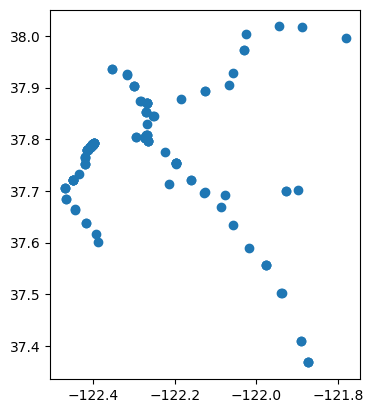

In [ ]:
bart = gpd.read_file(os.path.join(DATA_DIR, "raw/transit/BART-Stations-tracks-entrances-121025.kmz_/doc.kml"), driver="KML")
bart.plot()

In [ ]:
def calculate_nearest_bart(stations: gpd.GeoDataFrame, bart: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    CRS_METRIC = "EPSG:26910"

    stations_m = stations.to_crs(CRS_METRIC)
    bart_m = bart.to_crs(CRS_METRIC)

    # for each station, find distance to nearest BART stop
    stations_m["dist_to_bart_m"] = stations_m.geometry.apply(
        lambda geom: bart_m.distance(geom).min()
    )
    stations_m["dist_to_bart_mi"] = (stations_m["dist_to_bart_m"] / 1609.34).round(3)

    return stations_m.to_crs("EPSG:4326")

In [ ]:
transit_gdf = calculate_nearest_bart(points, bart)
transit_gdf.head(5)

,id,start_count,end_count,combined_count,name,lat,long,geometry,dist_to_bart_m,dist_to_bart_mi
0,BK-A3,1613,1517,3130,College Ave at Alcatraz Ave,37.851376,-122.252523,POINT (-122.25252 37.85138),768.674477,0.478
1,BK-A7,3905,3879,7784,Vine St at Shattuck Ave,37.880222,-122.269592,POINT (-122.26959 37.88022),1028.151853,0.639
2,BK-B7,2222,2314,4536,Virginia St at Shattuck Ave,37.876573,-122.269528,POINT (-122.26953 37.87657),625.859588,0.389
3,BK-C1,1612,1911,3523,Fifth St at Delaware St,37.870407,-122.299676,POINT (-122.29968 37.87041),1471.628003,0.914
4,BK-C5,2970,2795,5765,North Berkeley BART,37.873856,-122.282988,POINT (-122.28299 37.87386),41.423604,0.026


In [ ]:
activity_gdf[['dist_to_bart_m', 'dist_to_bart_mi']] = transit_gdf[['dist_to_bart_m', 'dist_to_bart_mi']]
stations_gdf_all_vars = activity_gdf

# Clustering stations

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import numpy as np

def fit_gmm(stations: gpd.GeoDataFrame) -> gpd.GeoDataFrame:

    # select and drop any rows with missing values
    features = ["estimated_activity", "emp_pop_balance", "dist_to_bart_mi"]
    df = stations[features].dropna()

    # z-score normalize
    scaler = StandardScaler()
    X = scaler.fit_transform(df)

    # fit GMMs for k=2 to k=8, select best by BIC
    best_bic = np.inf
    best_k = None
    best_model = None

    for k in range(2, 9):
        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
        gmm.fit(X)
        bic = gmm.bic(X)
        print(f"k={k}, BIC={bic:.2f}")
        if bic < best_bic:
            best_bic = bic
            best_k = k
            best_model = gmm

    print(f"\nBest k: {best_k}")

    # assign cluster labels and posterior probabilities
    labels = best_model.predict(X)
    probs = best_model.predict_proba(X)

    stations = stations.copy()
    stations.loc[df.index, "cluster"] = labels
    for i in range(best_k):
        stations.loc[df.index, f"prob_cluster_{i}"] = probs[:, i]

    return stations, best_model, scaler

In [ ]:
stations_clustered, model, scaler = fit_gmm(stations_gdf_all_vars)

# cluster means in original units
features = ["estimated_activity", "emp_pop_balance", "dist_to_bart_mi"]
print(stations_clustered.groupby("cluster")[features].mean().round(2))

# how many stations in each cluster
print(stations_clustered["cluster"].value_counts().sort_index())

k=2, BIC=950.22
k=3, BIC=944.73
k=4, BIC=832.80
k=5, BIC=834.77
k=6, BIC=841.77
k=7, BIC=891.73
k=8, BIC=906.72

Best k: 4
         estimated_activity  emp_pop_balance  dist_to_bart_mi
cluster                                                      
0.0                13546.09             1.47             1.24
1.0                67428.46             4.21             0.16
2.0                32648.78             1.38             0.39
3.0                16299.79             0.34             0.60
cluster
0.0    23
1.0    13
2.0    32
3.0    86
Name: count, dtype: int64


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
stations_clustered["cluster"] = stations_clustered["cluster"].astype(int)
# convert geometry from polygons (for buffers) back to points
stations_clustered["geometry"] = gpd.points_from_xy(
    stations_clustered["long"],
    stations_clustered["lat"]
)
stations_clustered = gpd.GeoDataFrame(stations_clustered, geometry="geometry", crs="EPSG:4326")
stations_clustered.head()

,id,start_count,end_count,combined_count,name,lat,long,buffer_area_m2,estimated_pop,buffer_area_km2,pop_per_km2,buffer_radius_m,n_blockgroups,estimated_jobs,estimated_activity,emp_pop_balance,geometry,dist_to_bart_m,dist_to_bart_mi,cluster,prob_cluster_0,prob_cluster_1,prob_cluster_2,prob_cluster_3
0,BK-A3,1613,1517,3130,College Ave at Alcatraz Ave,37.851376,-122.252523,2.007391e+06,9668,2.0074,4816.2,800,16,5448,15116,0.5635,POINT (-122.25252 37.85138),768.674477,0.478,3,2.150040e-02,2.826234e-16,0.027680,9.508196e-01
1,BK-A7,3905,3879,7784,Vine St at Shattuck Ave,37.880222,-122.269592,2.007391e+06,12025,2.0074,5990.5,800,20,15618,27643,1.2987,POINT (-122.26959 37.88022),1028.151853,0.639,2,4.742437e-03,7.775078e-18,0.995258,6.021269e-14
2,BK-B7,2222,2314,4536,Virginia St at Shattuck Ave,37.876573,-122.269528,2.007391e+06,13222,2.0074,6586.8,800,21,24380,37602,1.8438,POINT (-122.26953 37.87657),625.859588,0.389,2,2.565371e-07,8.659936e-08,1.000000,1.661738e-35
3,BK-C1,1612,1911,3523,Fifth St at Delaware St,37.870407,-122.299676,2.007391e+06,5533,2.0074,2756.3,800,11,5062,10595,0.9149,POINT (-122.29968 37.87041),1471.628003,0.914,0,9.275538e-01,5.342132e-30,0.072389,5.729280e-05
4,BK-C5,2970,2795,5765,North Berkeley BART,37.873856,-122.282988,2.007391e+06,10677,2.0074,5318.8,800,15,6286,16963,0.5887,POINT (-122.28299 37.87386),41.423604,0.026,3,8.950495e-03,3.129658e-15,0.000070,9.909797e-01


In [ ]:
stations_clustered.to_file(os.path.join(DATA_DIR, "cleaned/clustered/stations25_clustered.geojson"), driver="GeoJSON")

# Add cluster variables to all other years' data

In [ ]:
def add_cluster_vars_to_gdf(year):
  f_path = os.path.join(DATA_DIR, f'cleaned/stations by year/stations_{year}.geojson')
  points = load_points(f_path)
  # remove san jose
  points = points[~points["id"].str.startswith("SJ")]
  print(f"{len(points)} points loaded")
  points[['estimated_pop', 'n_blockgroups', 'estimated_jobs', 'estimated_activity', 'emp_pop_balance', 'dist_to_bart_mi', 'cluster']] = (
      stations_clustered[['estimated_pop', 'n_blockgroups', 'estimated_jobs', 'estimated_activity', 'emp_pop_balance', 'dist_to_bart_mi', 'cluster']]
  )
  return points

stations20_clustered = add_cluster_vars_to_gdf(20)
stations21_clustered = add_cluster_vars_to_gdf(21)
stations22_clustered = add_cluster_vars_to_gdf(22)
stations23_clustered = add_cluster_vars_to_gdf(23)
stations24_clustered = add_cluster_vars_to_gdf(24)

131 points loaded
140 points loaded
132 points loaded
132 points loaded
134 points loaded


In [ ]:
stations20_clustered.to_file(os.path.join(DATA_DIR, "cleaned/clustered/stations20_clustered.geojson"), driver="GeoJSON")
stations21_clustered.to_file(os.path.join(DATA_DIR, "cleaned/clustered/stations21_clustered.geojson"), driver="GeoJSON")
stations22_clustered.to_file(os.path.join(DATA_DIR, "cleaned/clustered/stations22_clustered.geojson"), driver="GeoJSON")
stations23_clustered.to_file(os.path.join(DATA_DIR, "cleaned/clustered/stations23_clustered.geojson"), driver="GeoJSON")
stations24_clustered.to_file(os.path.join(DATA_DIR, "cleaned/clustered/stations24_clustered.geojson"), driver="GeoJSON")